In [1]:
import jax
import jax.numpy as jnp
import jax.random as jxr
from clds.models import CLDS, WeightSpaceGaussianProcess, CLDS2, ParamsCLDS2
from clds import utils
from clds.simulate import simulate_hd_data
from functools import partial
import matplotlib.pyplot as plt

/opt/homebrew/Caskroom/miniforge/base/envs/clds-test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
num_timesteps = 100
n_batches = 100
n_neurons = 10
latent_dim = 2
_sigma, _kappa, _period = 0.5, 0.1, 2*jnp.pi
torus_basis_funcs = utils.Tm_basis(5, M_conditions=1, sigma=_sigma, kappa=_kappa, period=_period)

model_sim = CLDS2(
    state_dim=latent_dim, 
    emission_dim=n_neurons,
    basis=torus_basis_funcs,
    use_dynamics_prior=True,
    use_dynamics_bias=True,
    use_emissions_prior=False,
    use_emissions_bias=False,
    use_initial_prior=True,
    )

seed = 0
key = jxr.PRNGKey(seed)
thetas, _, _ = simulate_hd_data(n_steps=num_timesteps, n_neurons=n_neurons, seed=seed)
sim_params = model_sim.initialize_params(num_timesteps, seed=seed)
model_sim.params = sim_params
X, Y = jax.vmap(partial(model_sim.predict, seed=seed))(thetas)


Iter 300/300, log-prob = -176688.33, marginal log-lik = -166467.22: 100%|██████████| 300/300 [00:04<00:00, 68.09it/s]


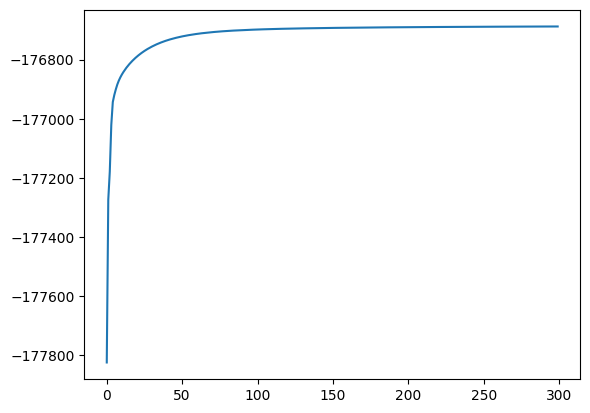

In [6]:
model_fit = CLDS2(
    state_dim=latent_dim, 
    emission_dim=n_neurons,
    basis=torus_basis_funcs,
    use_dynamics_prior=True,
    use_dynamics_bias=True,
    use_emissions_prior=False,
    use_emissions_bias=False,
    use_initial_prior=True,
    )
fit_params, log_probs = model_fit.fit(emissions=Y, conditions=thetas, num_iters=300, seed=0)
plt.plot(log_probs)

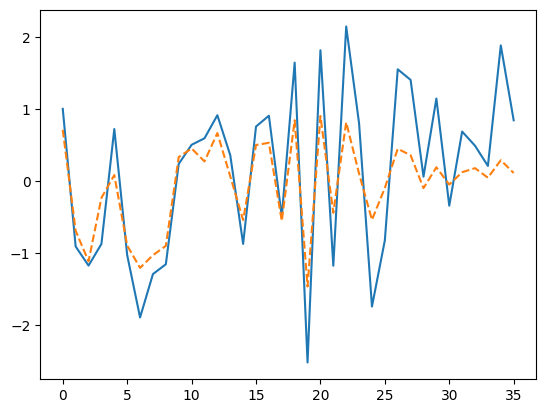

In [7]:
plt.plot(sim_params.dynamics_weights.ravel())
plt.plot(fit_params.dynamics_weights.ravel(),'--')

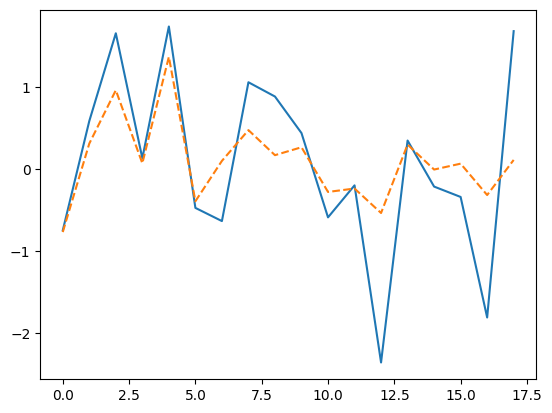

In [8]:
plt.plot(sim_params.dynamics_bias.ravel())
plt.plot(fit_params.dynamics_bias.ravel(),'--')

In [16]:
print(sim_params.dynamics_cov)
print(fit_params.dynamics_cov)

[[1. 0.]
 [0. 1.]]
[[5.209103  1.6133076]
 [1.6133076 6.939347 ]]


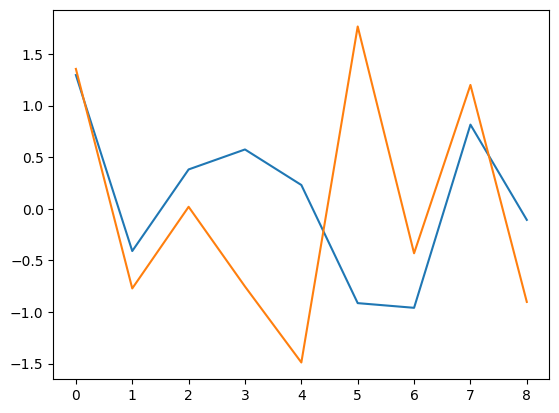

In [ ]:
sim_params = model_sim.params
plt.plot(sim_params.initial_mean.squeeze())

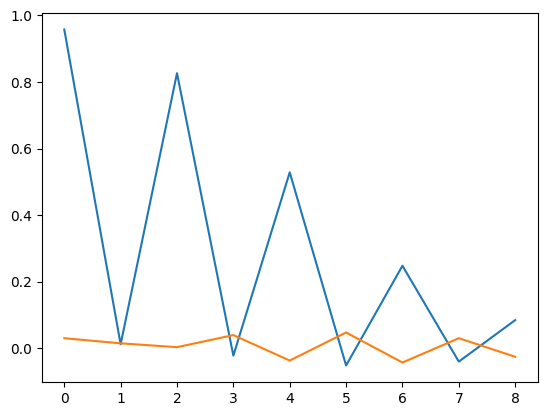

In [5]:
plt.plot(model_fit.params.initial_mean.squeeze())